In [1]:
# Import packages
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
graph.make_bigandbold()
from scipy import stats
from matplotlib import cm
import statsmodels.formula.api as smf

In [2]:
experiment_names = ['ltFLiPAKARmemEEGEMG0046',
                   'kgFLiPAKAREEGEMG0008',
                   'ltFLiPAKARmemEEGEMG0119']
mouse_names = ['4499',
              '4501',
              '5484']

In [3]:
##------------------------------------ PKI Data ---------------------------##
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, pull_baseline = True, 
                                          baseline_idxs = baseline_idxs)

# Set FLiP class parameters and build classes
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 40
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False
shuffled = True

FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                     exclude_acqs = excluded_acqs)
MA_to_NREM = True
NREM_wake_only = False
if NREM_wake_only:
    NREM_status = '_NREMonly'
else:
    NREM_status = ''
if MA_to_NREM:
    MA_status = '_noMA'
else:
    MA_status = ''
data_keys = ['Distance', experimental_sensor, 'Timepoints']
if shuffled:
    data_keys.append('Shuffled')
grouped_experiments = {a:{'Experiment Classes':[FLP_classes_dict['Experiment Classes'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Classes'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Experiment Names':[FLP_classes_dict['Experiment Names'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Names'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Wake Distance Data': {k: [] for k in data_keys},
                          'Sleep Duration Data': {k: [] for k in data_keys}}
                            for a in np.unique(FLP_classes_dict['Animal Names'])}
for a in grouped_experiments.keys():
    for b, FLP_exp in zip(grouped_experiments[a]['Experiment Names'], grouped_experiments[a]['Experiment Classes']):
        time_range = [FLP_exp.Time[0], FLP_exp.Time[-1]]
        data_dict = PKA.LFT_WakeSleepDistance(FLP_exp, time_range, MA_to_NREM = MA_to_NREM, NREM_wake_only = NREM_wake_only, 
                                        shuffled = shuffled,buffer = 0, get_wake_distance = True, get_sleep_distance = False)
        for key, value in data_dict.items():
            grouped_experiments[a]['Wake Distance Data'][key].append(value[~np.isnan(data_dict['Distance'])])
        
        data_dict = PKA.LFT_WakeSleepDistance(FLP_exp, time_range, MA_to_NREM = MA_to_NREM, NREM_wake_only = NREM_wake_only, 
                                        shuffled = shuffled,buffer = 0, get_wake_distance = False, get_sleep_distance = True)
        for key, value in data_dict.items():
            grouped_experiments[a]['Sleep Duration Data'][key].append(value[~np.isnan(data_dict['Distance'])])
        if len(grouped_experiments[a]['Wake Distance Data'][key][-1]) != len(grouped_experiments[a]['Sleep Duration Data'][key][-1]):
            real_val = min([len(grouped_experiments[a]['Wake Distance Data'][key][-1]),
                            len(grouped_experiments[a]['Sleep Duration Data'][key][-1])])
            for key in data_dict.keys():
                grouped_experiments[a]['Wake Distance Data'][key][-1] = grouped_experiments[a]['Wake Distance Data'][key][-1][:real_val]
                grouped_experiments[a]['Sleep Duration Data'][key][-1] = grouped_experiments[a]['Sleep Duration Data'][key][-1][:real_val]
    grouped_experiments[a]['Grouped Data'] = {
        experimental_sensor: np.concatenate([stats.zscore(w) for w in grouped_experiments[a]['Wake Distance Data'][experimental_sensor]]),
        'Wake Distance': np.concatenate(grouped_experiments[a]['Wake Distance Data']['Distance']),
        'Sleep Duration': np.concatenate([stats.zscore(w) for w in grouped_experiments[a]['Sleep Duration Data']['Distance']])}
    if shuffled:
        grouped_experiments[a]['Grouped Data']['Shuffled'] = np.concatenate(
            [stats.zscore(w) for w in grouped_experiments[a]['Wake Distance Data']['Shuffled']])
num_LFT_bins = 9
waking_binsize = 16

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_23999/700570949.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You didn't put any filter values
You didn't put any filter values
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(26), np.uint8(27)]
I will fill these with 0s


/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_23999/2934406149.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap_name)
/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_23999/2934406149.py:32: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  axes[2].errorbar(bin_centers, np.nanmean(all_wakeprops_EXP, axis = 0), yerr = stats.sem(all_wakeprops_EXP, axis = 0, nan_policy = 'omit'),
/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_23999/2934406149.py:35: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of re

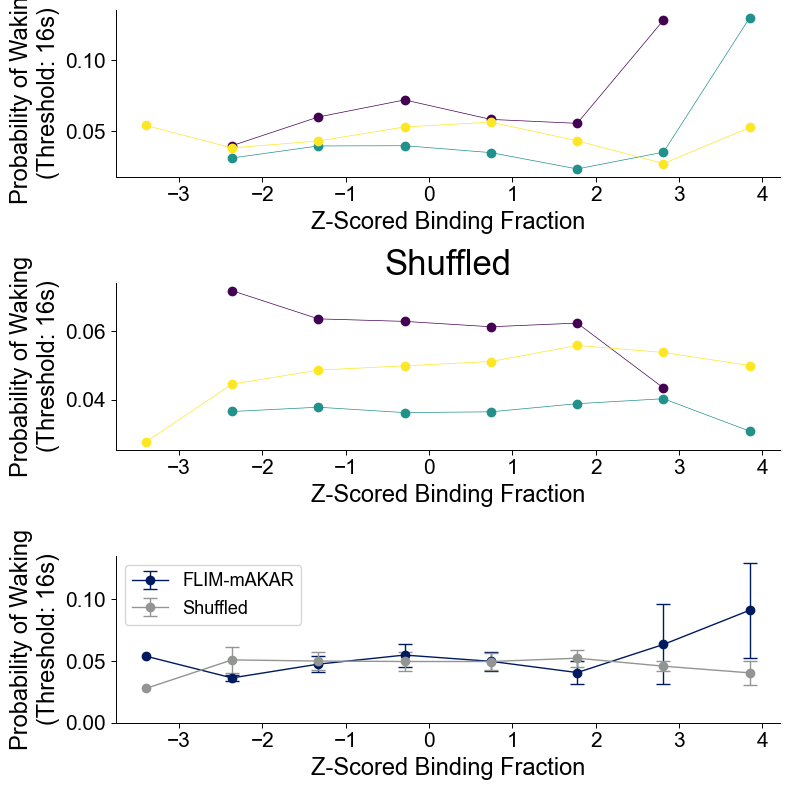

In [5]:
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/Wake_probability/'
num_animals = len(np.unique(FLP_classes_dict['Animal Names']))
cmap_name = 'viridis'
colormap = cm.get_cmap(cmap_name)
colors_list = colormap(np.linspace(0, 1, num_animals))
region = 'mPFC'

all_wakeprops_EXP = np.zeros([num_animals, num_LFT_bins-1])
all_wakeprops_EXP[:] = np.nan
all_wakeprops_SHUFF = np.zeros([num_animals, num_LFT_bins-1])
all_wakeprops_SHUFF[:] = np.nan

all_vals = np.concatenate([grouped_experiments[a]['Grouped Data'][experimental_sensor] for a in grouped_experiments.keys()])
bin_edges =  np.linspace(min(all_vals), max(all_vals),9)

fig, axes = plt.subplots(figsize = [8, 8], nrows = 3)
for i,a in enumerate(grouped_experiments.keys()):
    fig, axes[0], wake_prop_EXP, bin_centers = PKA.plot_wake_probability(fig, axes[0], 
                                                                     grouped_experiments[a]['Grouped Data'][experimental_sensor], 
                                                            grouped_experiments[a]['Grouped Data']['Wake Distance'], bin_edges,
                                                           waking_binsize = waking_binsize, include_n = False, savedir = False, 
                                                            color = colors_list[i], confidence_int = False)
    fig, axes[1], wake_prop_SHUFF, bin_centers = PKA.plot_wake_probability(fig, axes[1], 
                                                                            grouped_experiments[a]['Grouped Data']['Shuffled'], 
                                                            grouped_experiments[a]['Grouped Data']['Wake Distance'], bin_edges,
                                                           waking_binsize = waking_binsize, include_n = False, savedir = False, 
                                                            color = colors_list[i], confidence_int = False)

    all_wakeprops_EXP[i] = wake_prop_EXP[:,0]/wake_prop_EXP[:,1]
    all_wakeprops_SHUFF[i] = wake_prop_SHUFF[:,0]/wake_prop_SHUFF[:,1]

axes[2].errorbar(bin_centers, np.nanmean(all_wakeprops_EXP, axis = 0), yerr = stats.sem(all_wakeprops_EXP, axis = 0, nan_policy = 'omit'),  
            fmt = 'o', color = '#001A5F', capsize = 5, linewidth = 1, linestyle = '-', label = 'FLIM-mAKAR')

axes[2].errorbar(bin_centers, np.nanmean(all_wakeprops_SHUFF, axis = 0), yerr = stats.sem(all_wakeprops_SHUFF, axis = 0, nan_policy = 'omit'),  
            fmt = 'o', color = '#929591', capsize = 5, linewidth = 1, linestyle = '-', label = 'Shuffled')

axes[2].legend(fontsize = 13)
graph.thick_axes(fig, axes, width = 0.7)
axes[2].set_ylim([0,axes[2].get_ylim()[1]])

graph.label_axes(axes[1], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction', 
                 title = 'Experimental')
graph.label_axes(axes[1], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction', 
                 title = 'Shuffled')
graph.label_axes(axes[2], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction')

fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'WakingProb_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'_PKI.png'))
fig.savefig(os.path.join(fig_savedir, 'WakingProb_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'_PKI.ps'))


Observed difference in decay rates: -0.0780
P-value (permutation test): 4.91e-01


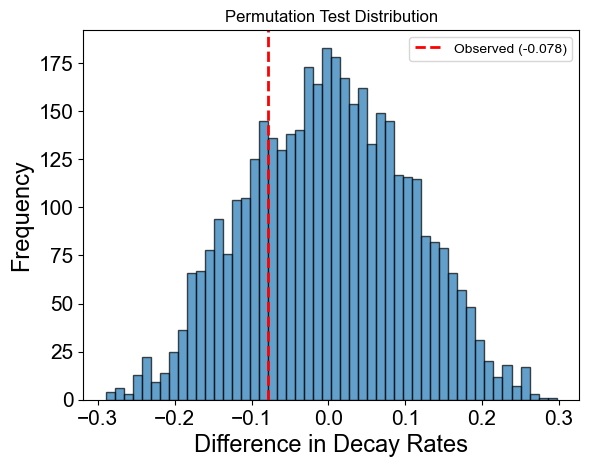

EXPERIMENTAL:
Position β: 0.057901
P-value: 1.691989e-01

SHUFFLED:
Position β: 0.012308
P-value: 5.081840e-01


In [8]:
##------------------------------------ Stats ---------------------------##
position = list(range(1,num_LFT_bins))*len(grouped_experiments.keys())
subject_id = np.concatenate([[e]*8 for e in grouped_experiments.keys()])
measurements_exp = np.concatenate(all_wakeprops_EXP)
measurements_shuff = np.concatenate(all_wakeprops_SHUFF)
data = pd.DataFrame({
            'position': list(position) * 2,
            'subject_id': list(subject_id) * 2,
            'measurement': list(measurements_exp) + list(measurements_shuff),  # your measurements
            'log_measurement': list(np.log(measurements_exp)) + list(np.log(measurements_shuff)),
            'condition': ['experimental']*len(measurements_exp) + ['shuffled']*len(measurements_shuff)  # or however you've organized it
            })
data_clean = data.dropna(subset=['log_measurement', 'position', 'condition', 'subject_id'])
#Test to confirm due to shuffled data
p_perm = PKA.WakeProb_PermutationTest(data)

#Test with mixed linear model 
#Experimental only
df_exp = data_clean[data_clean['condition'] == 'experimental']
model_exp = smf.mixedlm('log_measurement ~ position', 
                        data=df_exp, 
                        groups=df_exp['subject_id']).fit()

print("EXPERIMENTAL:")
print(f"Position β: {model_exp.params['position']:.6f}")
print(f"P-value: {model_exp.pvalues['position']:.6e}")

# Shuffled only
df_shuf = data_clean[data_clean['condition'] == 'shuffled']
model_shuf = smf.mixedlm('log_measurement ~ position', 
                         data=df_shuf, 
                         groups=df_shuf['subject_id']).fit()

print("\nSHUFFLED:")
print(f"Position β: {model_shuf.params['position']:.6f}")
print(f"P-value: {model_shuf.pvalues['position']:.6e}")
